# SAM AI Technologies - Data Analyst Internship

## Task 2: Cuisine Combination Analysis

### Objective
The objective of this task is to identify the most common combinations of cuisines in the restaurant dataset and determine whether certain cuisine combinations tend to have higher ratings.

### Tools Used
- Python
- Pandas
- Matplotlib

### Dataset
Zomato Restaurant Dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
dataset_url = "https://raw.githubusercontent.com/radhika-patel017/SAM-AI-Tech-Task/main/Zomato-Dataset.csv"

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
df.head()

,Restaurant ID,Restaurant Name,Country,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,3400025,Jahanpanah,India,1,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,...,Indian Rupees(Rs.),No,No,No,No,3,3.9,Yellow,Good,140
1,3400341,Rangrezz Restaurant,India,1,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,...,Indian Rupees(Rs.),No,No,No,No,2,3.5,Yellow,Good,71
2,3400005,Time2Eat - Mama Chicken,India,1,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra Cantt,"Agra Cantt, Agra",78.011608,27.160832,...,Indian Rupees(Rs.),No,No,No,No,2,3.6,Yellow,Good,94
3,3400021,Chokho Jeeman Marwari Jain Bhojanalya,India,1,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",Civil Lines,"Civil Lines, Agra",77.998092,27.195928,...,Indian Rupees(Rs.),No,No,No,No,2,4.0,Green,Very Good,87
4,3400017,Pinch Of Spice,India,1,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,...,Indian Rupees(Rs.),No,No,No,No,3,4.2,Green,Very Good,177


In [11]:
df.shape

(9549, 22)

In [12]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country', 'Country Code', 'City',
       'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude',
       'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [13]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.dropna(subset=["Cuisines"]).copy()
df.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (9540, 22)


In [16]:
def normalize_cuisines(cuisine):
    cuisine_list = [item.strip() for item in cuisine.split(",")]
    cuisine_list.sort()
    return ", ".join(cuisine_list)

df["Cuisine Combination"] = df["Cuisines"].apply(normalize_cuisines)

In [17]:
multi_cuisine = df[
    df["Cuisine Combination"].str.contains(",")
]

multi_cuisine.head()

,Restaurant ID,Restaurant Name,Country,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine Combination
0,3400025,Jahanpanah,India,1,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,...,No,No,No,No,3,3.9,Yellow,Good,140,"Mughlai, North Indian"
1,3400341,Rangrezz Restaurant,India,1,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,...,No,No,No,No,2,3.5,Yellow,Good,71,"Mughlai, North Indian"
4,3400017,Pinch Of Spice,India,1,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,...,No,No,No,No,3,4.2,Green,Very Good,177,"Chinese, Mughlai, North Indian"
5,3400325,MoMo Cafe,India,1,Agra,"Courtyard by Marriott Agra, Phase 2, Fatehabad...","Courtyard by Marriott Agra, Tajganj","Courtyard by Marriott Agra, Tajganj, Agra",0.000000,0.000000,...,No,No,No,No,4,4.0,Green,Very Good,45,"European, North Indian"
6,3400059,Peshawri - ITC Mughal,India,1,Agra,"ITC Mughal, Fatehabad Road, Tajganj, Agra","ITC Mughal, Tajganj","ITC Mughal, Tajganj, Agra",78.044095,27.160934,...,No,No,No,No,4,4.3,Green,Very Good,133,"Mughlai, North Indian"


In [18]:
top_combinations = (
    multi_cuisine["Cuisine Combination"]
    .value_counts()
    .head(10)
)

top_combinations

,count
Cuisine Combination,
"Chinese, North Indian",616
"Mughlai, North Indian",394
"Chinese, Mughlai, North Indian",306
"Bakery, Desserts",181
"Chinese, Fast Food",159
"Fast Food, Pizza",142
"Chinese, North Indian, South Indian",135
"Mithai, Street Food",134
"Fast Food, North Indian",120


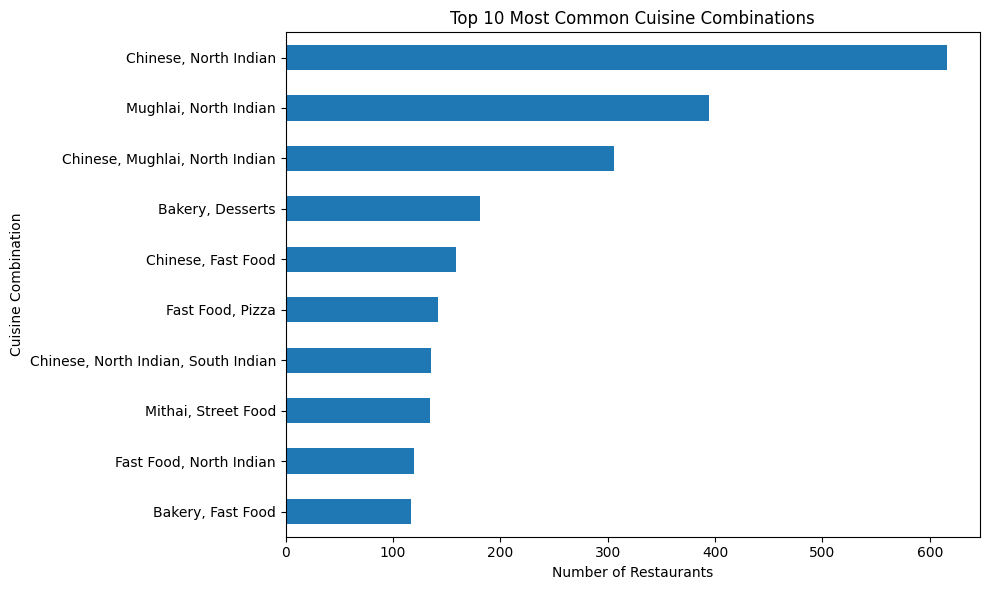

In [19]:
plt.figure(figsize=(10, 6))

top_combinations.sort_values().plot(kind="barh")

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.tight_layout()
plt.show()

### Insight

The most common cuisine combination in the dataset is **Chinese and North Indian**, appearing in **616 restaurants**.

It is followed by **Mughlai and North Indian** with **394 restaurants** and **Chinese, Mughlai and North Indian** with **306 restaurants**.

This shows that North Indian cuisine is frequently combined with Chinese and Mughlai cuisines.

In [20]:
rated_multi_cuisine = multi_cuisine[
    multi_cuisine["Aggregate rating"] > 0
]

In [22]:
cuisine_rating_analysis = (
    rated_multi_cuisine
    .groupby("Cuisine Combination")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean")
    )
    .reset_index()
)

cuisine_rating_analysis.head()

,Cuisine Combination,Restaurant_Count,Average_Rating
0,"Afghani, Chinese, Indian, Pakistani",1,4.1
1,"Afghani, Curry, Indian, Pakistani",1,3.9
2,"Afghani, Fast Food, North Indian",1,3.0
3,"Afghani, Hyderabadi, Indian, Pakistani",1,4.0
4,"Afghani, Mughlai",1,2.8


In [23]:
reliable_combinations = cuisine_rating_analysis[
    cuisine_rating_analysis["Restaurant_Count"] >= 10
]

In [24]:
top_rated_combinations = (
    reliable_combinations
    .sort_values("Average_Rating", ascending=False)
    .head(10)
)

top_rated_combinations

,Cuisine Combination,Restaurant_Count,Average_Rating
578,"Cafe, Continental, Italian",18,4.111111
48,"American, Burger",16,4.068750
1102,"Japanese, Sushi",20,4.060000
326,"Bakery, Cafe, Desserts",11,4.027273
591,"Cafe, Desserts",11,3.972727
622,"Cafe, Italian",12,3.933333
569,"Cafe, Continental",12,3.866667
226,"Asian, Chinese, Thai",19,3.773684
640,"Cafe, Tea",19,3.768421
1086,"Italian, Pizza",42,3.738095


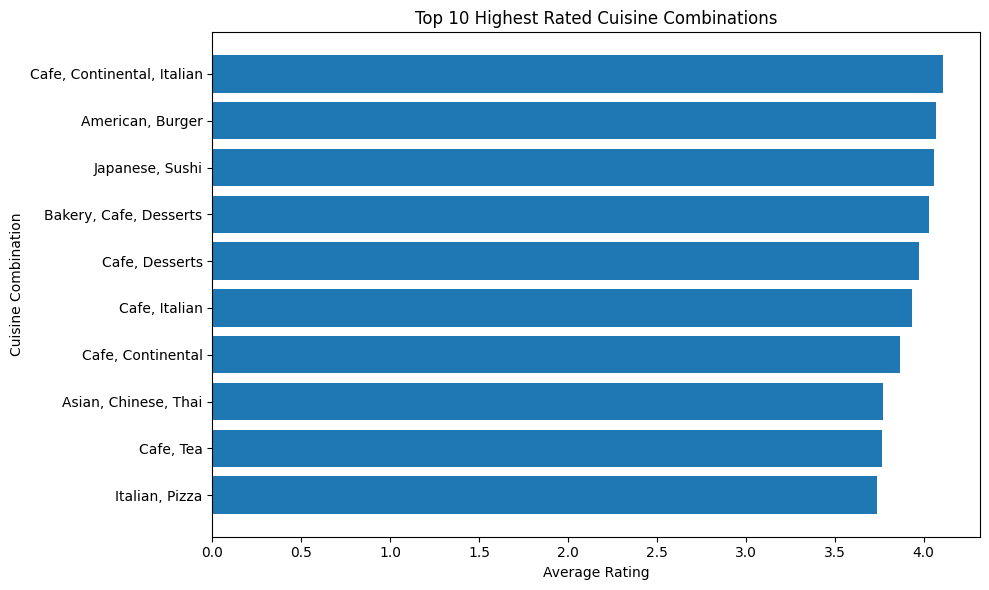

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_rated_combinations["Cuisine Combination"],
    top_rated_combinations["Average_Rating"]
)

plt.title("Top 10 Highest Rated Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Final Insights - Task 2

The most common cuisine combination in the dataset is **Chinese and North Indian**, appearing in **616 restaurants**.

It is followed by **Mughlai and North Indian** with **394 restaurants** and **Chinese, Mughlai and North Indian** with **306 restaurants**.

To reduce the influence of very small groups, only cuisine combinations represented by at least 10 rated restaurants were considered for the rating comparison.

Among these combinations, **Cafe, Continental and Italian** has the highest average rating of approximately **4.11**, based on 18 rated restaurants.

It is followed by **American and Burger** with an average rating of approximately **4.07**, and **Japanese and Sushi** with an average rating of approximately **4.06**.

The analysis shows that the most frequently available cuisine combinations are not necessarily the highest-rated combinations.

# Task 2 Conclusion

The analysis found that **Chinese and North Indian** is the most common multi-cuisine combination in the dataset, appearing in **616 restaurants**.

Among cuisine combinations represented by at least 10 rated restaurants, **Cafe, Continental and Italian** achieved the highest average rating of approximately **4.11**.

Overall, the analysis demonstrates that the most commonly available cuisine combinations are not necessarily the highest-rated combinations.